In [2]:
import pandas as pd

# Загружаем данные, поднимаясь на один уровень выше из папки notebooks
df = pd.read_csv('../data/raw/telco_churn.csv')

# Смотрим на первые 5 строк таблицы
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 1. Смотрим на общий размер таблицы (строки, столбцы)
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов\n")

# 2. Смотрим на типы данных и наличие пропусков
df.info()

Размер датасета: 7043 строк и 21 столбцов

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessB

In [4]:
# 1. Смотрим, сколько клиентов ушло (Yes) и сколько осталось (No)
print("Абсолютное количество клиентов:")
print(df['Churn'].value_counts())

# 2. Смотрим на процентное соотношение (доли от 0 до 1 умножаем на 100)
print("\nПроцентное соотношение:")
print(df['Churn'].value_counts(normalize=True) * 100)

Абсолютное количество клиентов:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Процентное соотношение:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


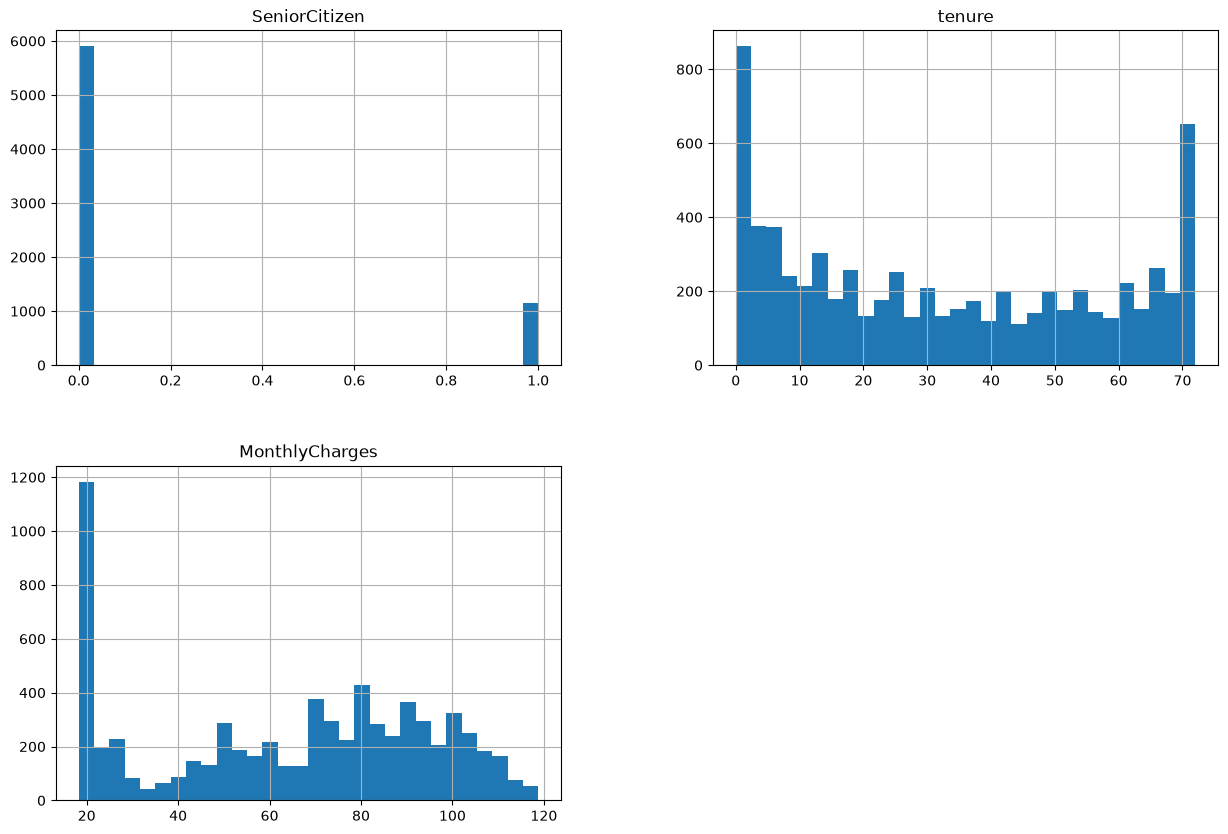

In [5]:
# 1. Удаляем уникальный идентификатор, он не несет пользы для модели
df.drop('customerID', axis=1, inplace=True)

# 2. Смотрим на распределение всех числовых признаков
# bins=30 разбивает данные на 30 "корзин" для гистограммы
# figsize задает размер картинки в дюймах (ширина, высота)
df.hist(bins=30, figsize=(15, 10))

# Показываем графики
import matplotlib.pyplot as plt
plt.show()

In [6]:
# 1. Автоматически находим все числовые столбцы
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Числовые признаки ({len(num_cols)}): {num_cols}\n")

# 2. Автоматически находим все категориальные (текстовые) столбцы
# Мы исключаем числа, чтобы не потерять столбцы, которые pandas считает "категориями"
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print(f"Категориальные признаки ({len(cat_cols)}): {cat_cols}")

Числовые признаки (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Категориальные признаки (17): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [7]:
# 1. Пытаемся принудительно превратить TotalCharges в число
# Ошибки (не-числа) заменяем на NaN (пропуски)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Проверяем, сколько пропусков появилось после этой операции
missing_count = df['TotalCharges'].isna().sum()
print(f"Количество пропусков в TotalCharges: {missing_count}")

# 3. Смотрим на сами строки, где были эти "фантики" (пропуски)
print("\nСтроки с пропусками:")
display(df[df['TotalCharges'].isna()])

Количество пропусков в TotalCharges: 11

Строки с пропусками:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
# 1. Заполняем пропуски в TotalCharges нулями (бизнес-логика: tenure=0 → TotalCharges=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Проверяем, что пропусков больше нет
print(f"Пропусков в TotalCharges после заполнения: {df['TotalCharges'].isna().sum()}")

# 3. Убеждаемся, что тип данных теперь числовой
print(f"Тип данных TotalCharges: {df['TotalCharges'].dtype}")

Пропусков в TotalCharges после заполнения: 0
Тип данных TotalCharges: float64


In [9]:
# Смотрим количество уникальных значений в каждом категориальном столбце
print("Количество уникальных значений в категориальных признаках:\n")
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} уникальных значений")

Количество уникальных значений в категориальных признаках:

gender: 2 уникальных значений
Partner: 2 уникальных значений
Dependents: 2 уникальных значений
PhoneService: 2 уникальных значений
MultipleLines: 3 уникальных значений
InternetService: 3 уникальных значений
OnlineSecurity: 3 уникальных значений
OnlineBackup: 3 уникальных значений
DeviceProtection: 3 уникальных значений
TechSupport: 3 уникальных значений
StreamingTV: 3 уникальных значений
StreamingMovies: 3 уникальных значений
Contract: 3 уникальных значений
PaperlessBilling: 2 уникальных значений
PaymentMethod: 4 уникальных значений
TotalCharges: 6531 уникальных значений
Churn: 2 уникальных значений


In [10]:
# Переопределяем списки, чтобы учесть изменения в типах данных
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

# Удаляем целевую переменную из списка признаков для EDA
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

print(f"Обновленные числовые признаки ({len(num_cols)}): {num_cols}\n")
print(f"Обновленные категориальные признаки ({len(cat_cols)}): {cat_cols}")

Обновленные числовые признаки (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Обновленные категориальные признаки (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\4104689012.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='viridis')
C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\4104689012.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='viridis')
C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\4104689012.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='viridis')
C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\4104689012.py:16: Futur

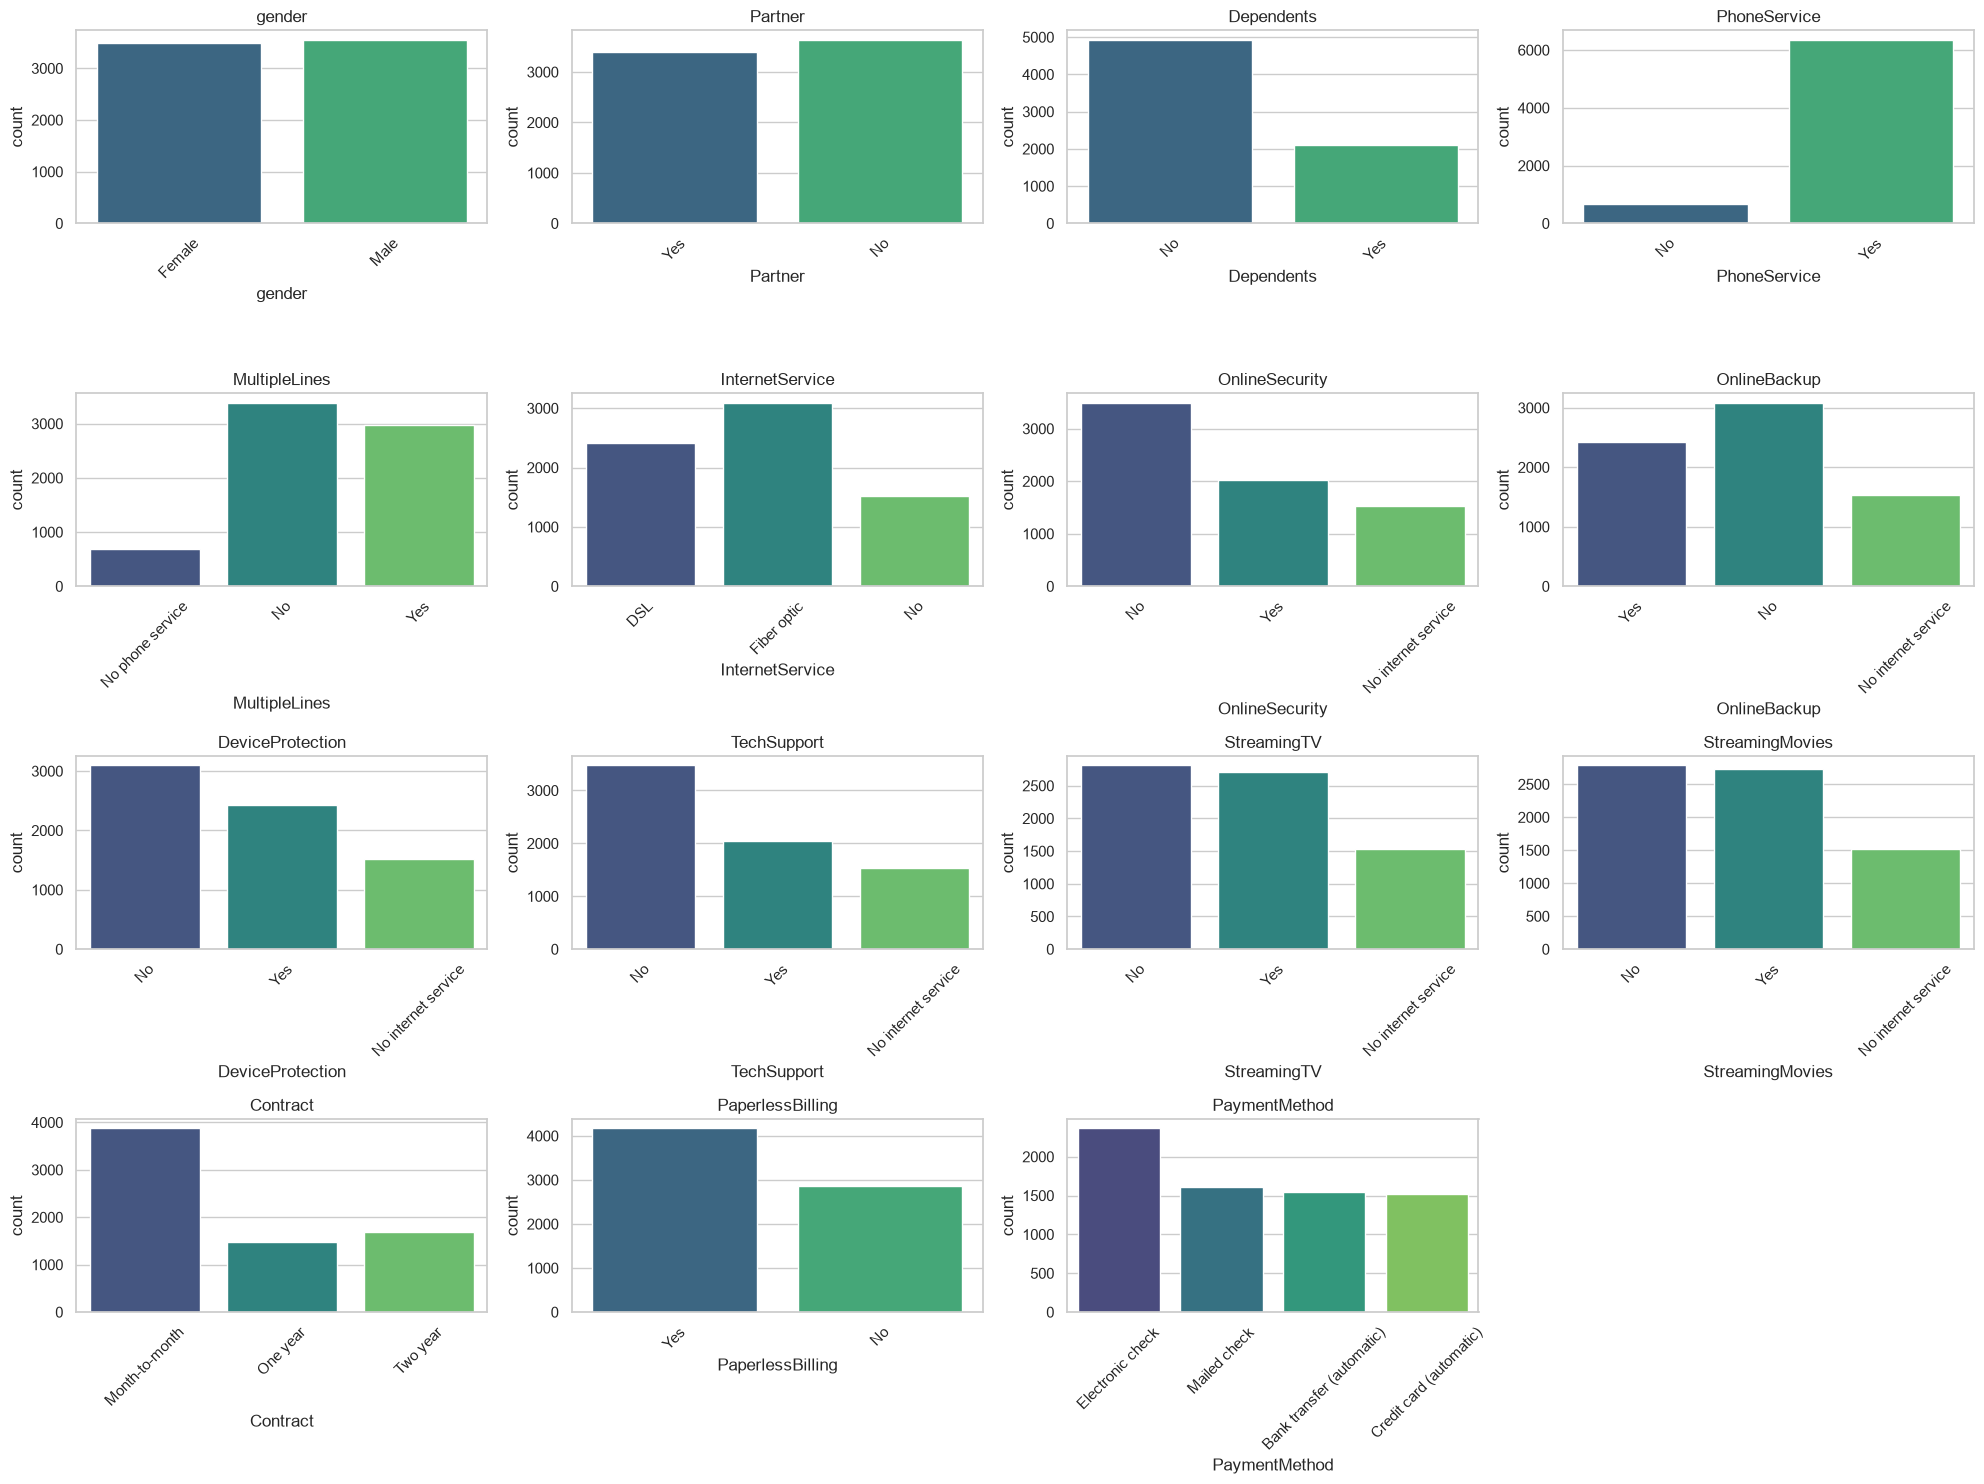

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Задаем красивый стиль графиков
sns.set_theme(style="whitegrid")

# Создаем сетку графиков: 4 строки, 4 столбца (фигура размером 20x15 дюймов)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

# Превращаем сетку 4x4 в плоский список из 16 осей (графиков)
axes = axes.flatten()

# Проходим циклом по всем категориальным признакам
for i, col in enumerate(cat_cols):
    # Рисуем countplot на текущей оси (axes[i])
    sns.countplot(x=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col)
    # Поворачиваем подписи под углом 45 градусов, чтобы длинные названия не слипались
    axes[i].tick_params(axis='x', rotation=45) 

# Если бы у нас было меньше 16 признаков, мы бы удалили пустые ячейки.
# У нас их ровно 16, но эта проверка - хороший профессиональный тон (best practice).
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
    
# Подгоняем отступы, чтобы заголовки графиков не перекрывали друг друга
plt.tight_layout()
plt.show()

In [12]:
# 1. Преобразуем Churn из текста в числа: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Создаем пустой список для хранения результатов
churn_by_category = {}

# 3. Для каждого категориального признака считаем средний отток
for col in cat_cols:
    # Группируем по признаку, берем столбец Churn, считаем среднее
    mean_churn = df.groupby(col)['Churn'].mean()
    churn_by_category[col] = mean_churn

# 4. Выводим результаты для первых 5 признаков (чтобы не засорять вывод)
for i, col in enumerate(list(churn_by_category.keys())[:5]):
    print(f"\n{col}:")
    print(churn_by_category[col])


gender:
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

Partner:
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

Dependents:
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

PhoneService:
PhoneService
No     0.249267
Yes    0.267096
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
No                  0.250442
No phone service    0.249267
Yes                 0.286099
Name: Churn, dtype: float64


C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\1716758905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Churn'], ax=axes[i], palette='viridis', errorbar=None)
C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\1716758905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Churn'], ax=axes[i], palette='viridis', errorbar=None)
C:\Users\gagindv\AppData\Local\Temp\ipykernel_628\1716758905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col], y=df['Churn'], ax=axes[i], palette='viridis', errorba

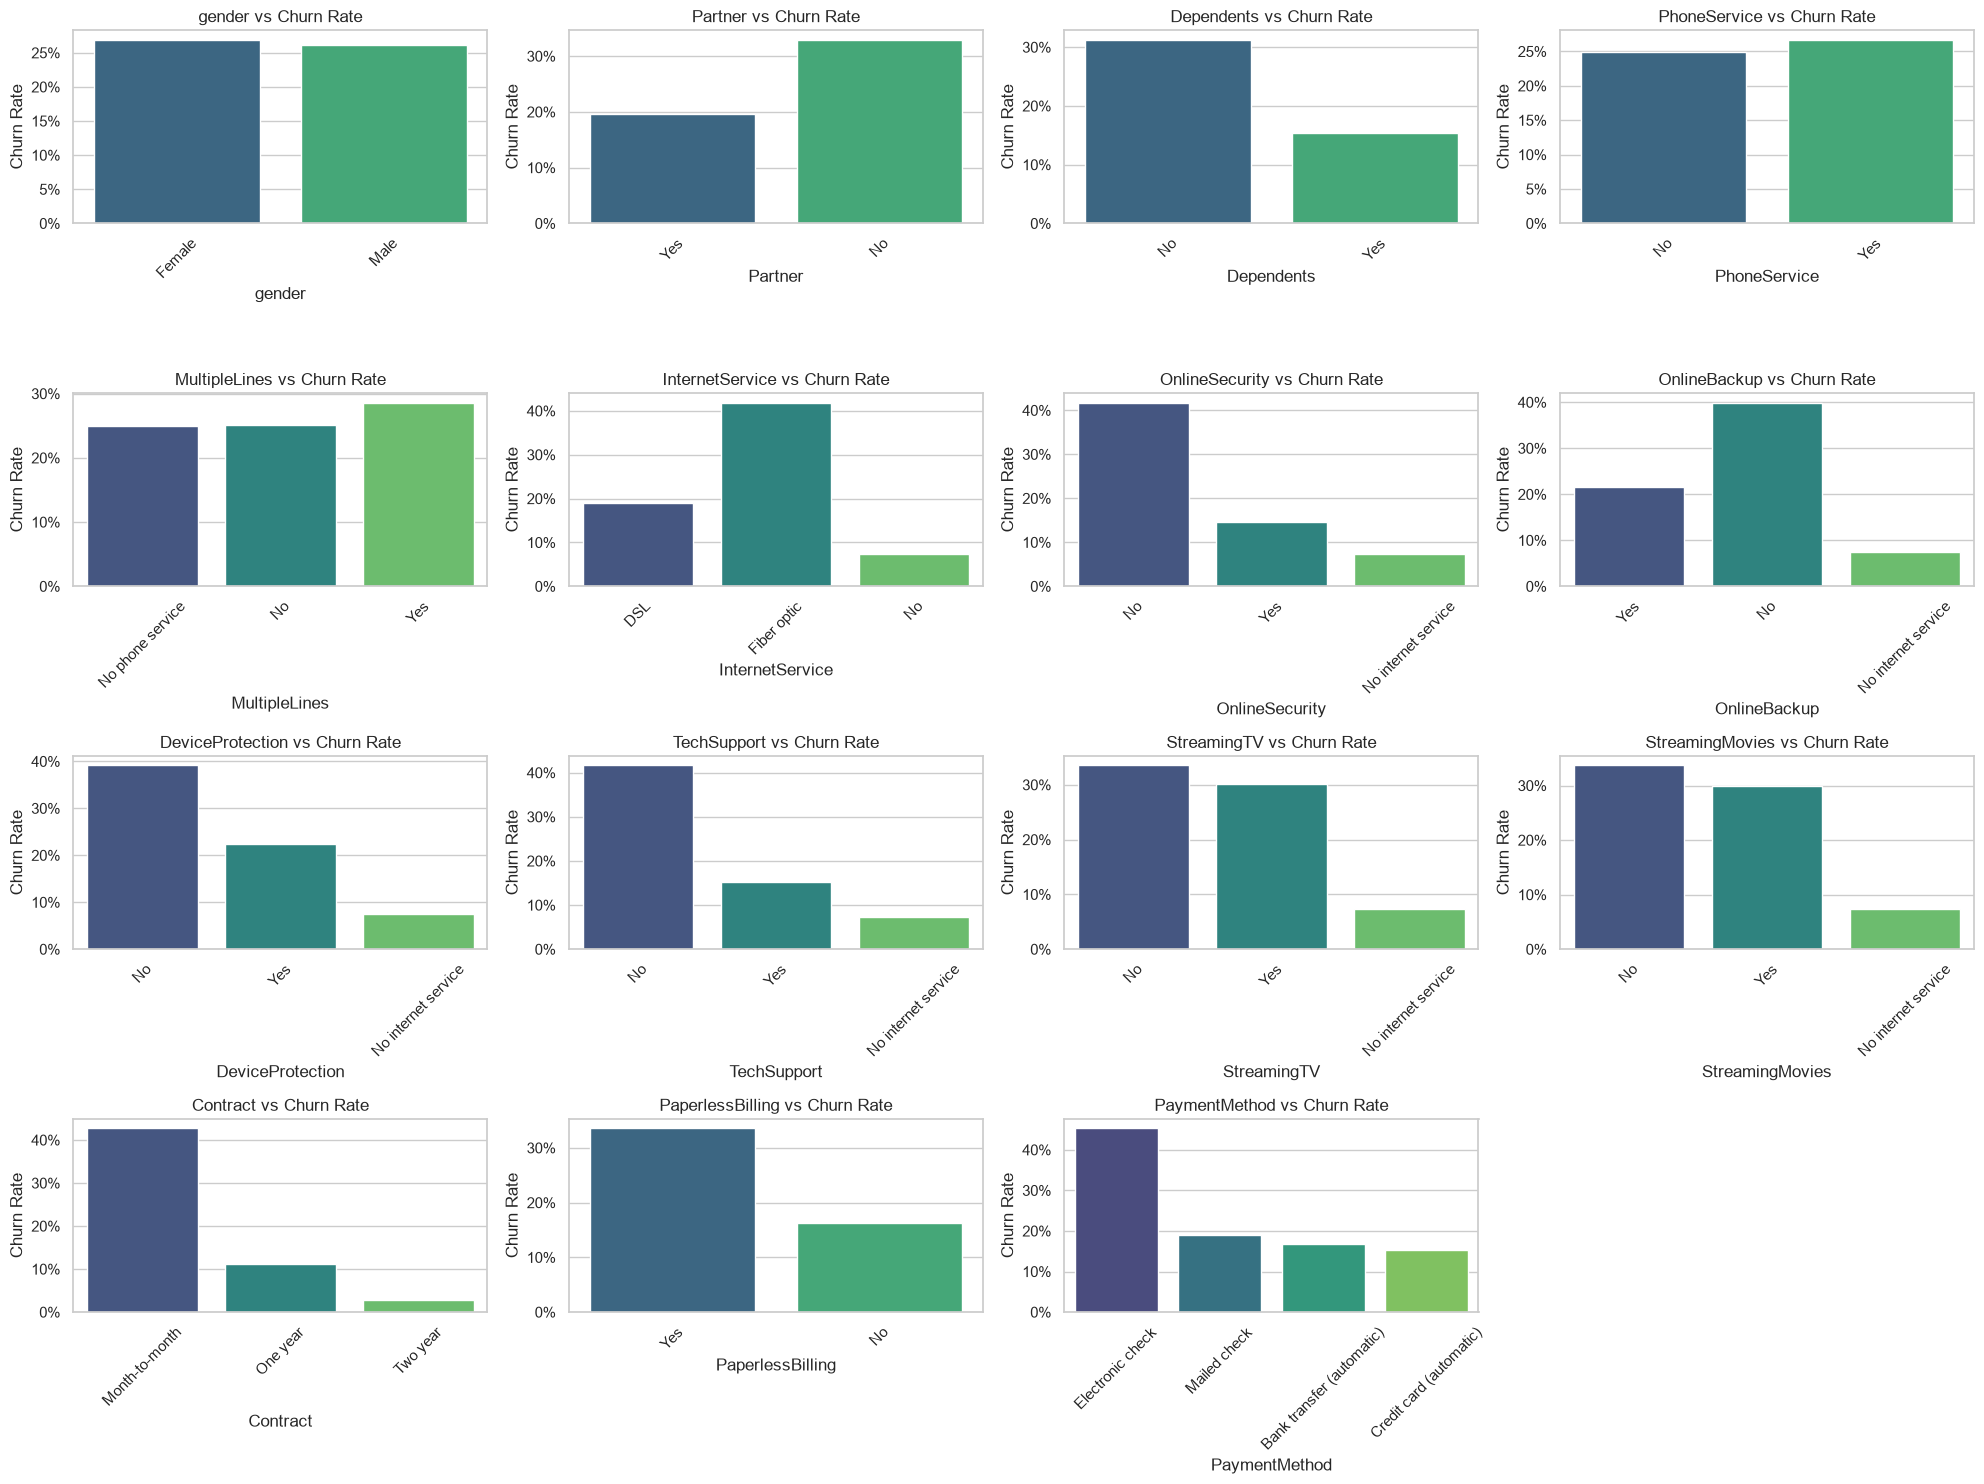

In [13]:
# Создаем сетку 4x4 для всех 16 категориальных признаков
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Рисуем barplot: по X - категория, по Y - целевая переменная (Churn)
    # errorbar=None убирает "усы" доверительных интервалов для чистоты картинки
    sns.barplot(x=df[col], y=df['Churn'], ax=axes[i], palette='viridis', errorbar=None)
    
    axes[i].set_title(f'{col} vs Churn Rate')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Форматируем ось Y в проценты (0.26 -> 26%)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Удаляем пустые графики, если их вдруг окажется больше, чем признаков
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()